# Structural-shift experiment: MMD and embedding progression


In [8]:
from pathlib import Path
from numpy.random import default_rng
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

MODELS = ('mlp', 'gnn', 'spectral_gnn')
COLORS = {
    'mlp': '#1f77b4',
    'gnn': '#ff7f0e',
    'spectral_gnn': '#2ca02c',
}
BASE_DIR = Path('__saved__/struct_shift')
RUN_DIR = Path("/home/bini/codes/GDA/KDD/SCGDA/__saved__/struct_shift/run_0217_225014")
EPOCH_COMPARE = 5
MAX_SAMPLED_NODES = 220
RNG = default_rng(7)


def _load_results(run_dir: Path, models: tuple[str, ...]) -> dict[str, dict[str, np.lib.npyio.NpzFile]]:
    results: dict[str, dict[str, np.lib.npyio.NpzFile]] = {}
    for name in models:
        results[name] = {
            'history': np.load(run_dir / f'{name}_history.npz'),
            'embeddings': np.load(run_dir / f'{name}_embeddings.npz'),
        }
    return results


def _find_epoch_index(epochs: np.ndarray, target: int) -> int:
    return int(np.argmin(np.abs(np.asarray(epochs) - target)))


def _sample_nodes(num_nodes: int, max_nodes: int, rng: np.random.Generator) -> np.ndarray:
    if num_nodes <= max_nodes:
        return np.arange(num_nodes)
    return rng.choice(num_nodes, size=max_nodes, replace=False)


def _pick_domain(payload: np.lib.npyio.NpzFile, domain: str):
    if domain == 'source':
        return (
            payload['source_train'],
            payload['source_test'],
            payload['source_train_labels'],
            payload['source_test_labels'],
        )
    return (
        payload['target_train'],
        payload['target_test'],
        payload['target_train_labels'],
        payload['target_test_labels'],
    )


def _fit_pca(x: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    x = np.asarray(x, dtype=np.float32)
    x = x - x.mean(axis=0, keepdims=True)
    _, _, vh = np.linalg.svd(x, full_matrices=False)
    return x.mean(axis=0), vh[:2]


def _project(x: np.ndarray, mean: np.ndarray, basis: np.ndarray) -> np.ndarray:
    return (np.asarray(x, dtype=np.float32) - mean) @ basis.T


def _scatter(ax, x: np.ndarray, y: np.ndarray, mean: np.ndarray, basis: np.ndarray, class_colors: dict[int, tuple[float, ...]], marker: str, alpha: float, edge: str | None = 'none') -> None:
    z = _project(x, mean, basis)
    for cls, c in class_colors.items():
        m = y == cls
        if np.any(m):
            ax.scatter(z[m, 0], z[m, 1], s=12, marker=marker, c=[c], alpha=alpha, edgecolors=edge, linewidths=0.3)


def _line(ax, x, y, color: str, label: str, style: str):
    ax.plot(x, y, color=color, ls=style, lw=1.4, label=label)


results = _load_results(RUN_DIR, MODELS)
print('run directory:', RUN_DIR)


run directory: /home/bini/codes/GDA/KDD/SCGDA/__saved__/struct_shift/run_0217_225014


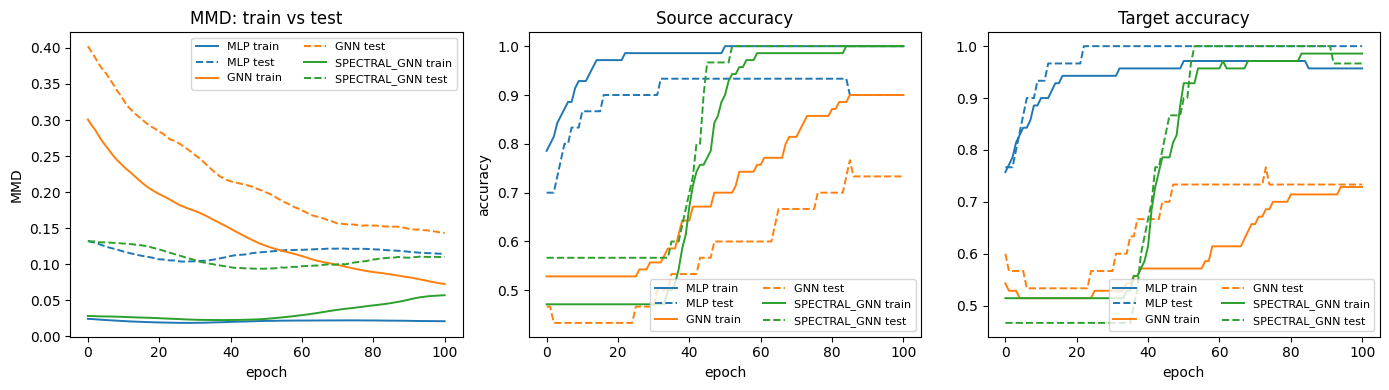

In [9]:
fig, (ax_mmd, ax_src, ax_tgt) = plt.subplots(1, 3, figsize=(14, 4), sharex=True)

for name in MODELS:
    h = results[name]['history']
    e = h['epoch']
    c = COLORS[name]

    _line(ax_mmd, e, h['mmd_train'], c, f'{name.upper()} train', '-')
    _line(ax_mmd, e, h['mmd_test'], c, f'{name.upper()} test', '--')
    _line(ax_src, e, h['source_train_acc'], c, f'{name.upper()} train', '-')
    _line(ax_src, e, h['source_test_acc'], c, f'{name.upper()} test', '--')
    _line(ax_tgt, e, h['target_train_acc'], c, f'{name.upper()} train', '-')
    _line(ax_tgt, e, h['target_test_acc'], c, f'{name.upper()} test', '--')

ax_mmd.set_title('MMD: train vs test')
ax_src.set_title('Source accuracy')
ax_tgt.set_title('Target accuracy')
ax_mmd.set_xlabel('epoch')
ax_src.set_xlabel('epoch')
ax_tgt.set_xlabel('epoch')
ax_mmd.set_ylabel('MMD')
ax_src.set_ylabel('accuracy')
ax_mmd.legend(ncol=2, fontsize=8)
ax_src.legend(ncol=2, fontsize=8)
ax_tgt.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()


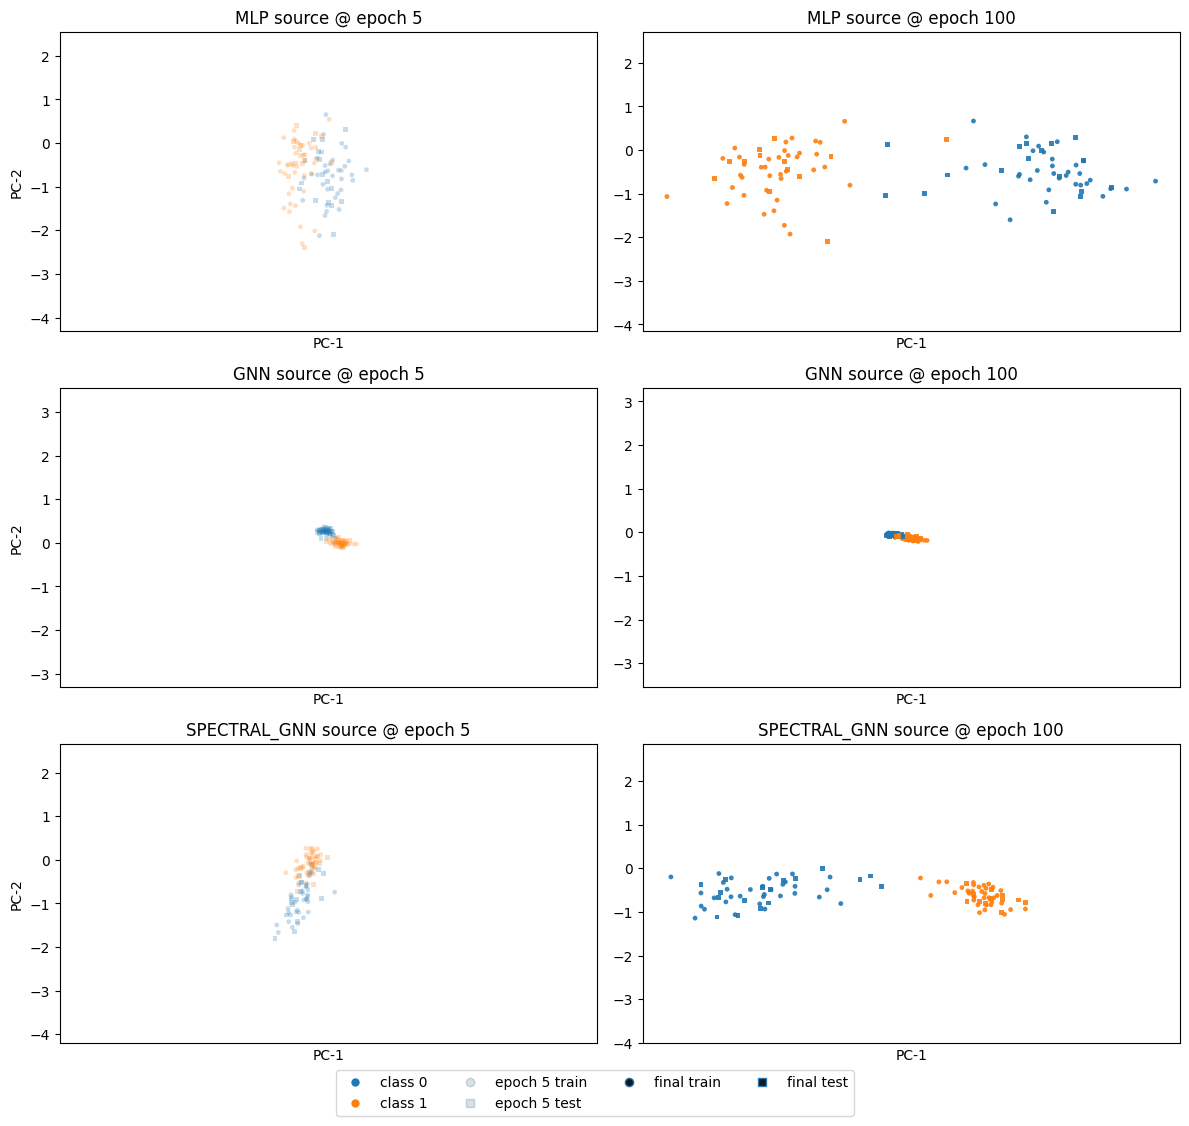

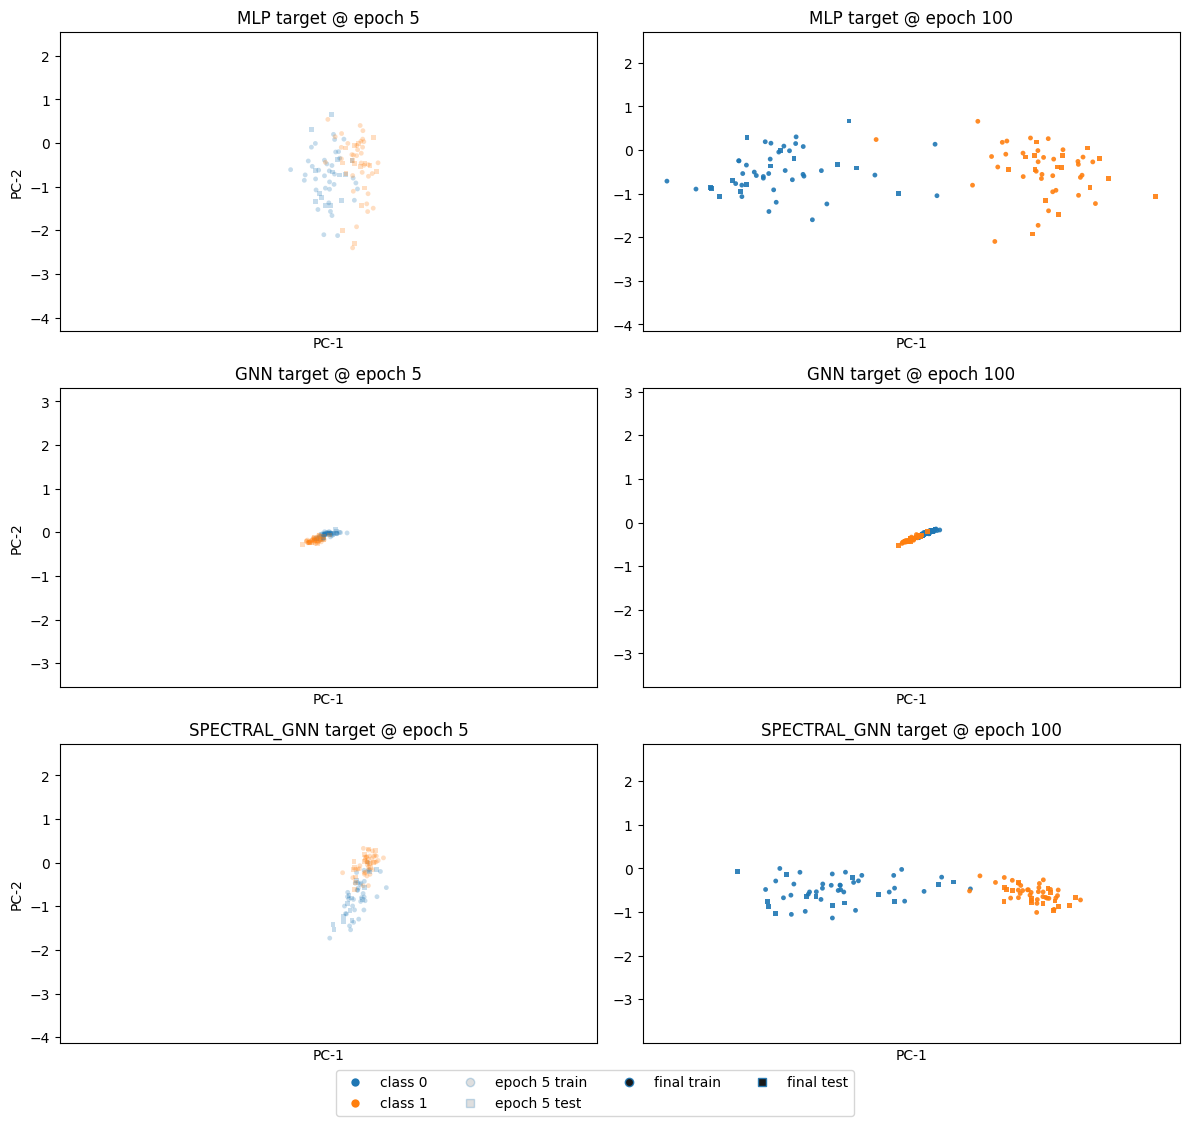

In [10]:
all_labels = np.unique(
    np.concatenate(
        [results[name]['embeddings']['source_train_labels'] for name in MODELS]
        + [results[name]['embeddings']['source_test_labels'] for name in MODELS]
        + [results[name]['embeddings']['target_train_labels'] for name in MODELS]
        + [results[name]['embeddings']['target_test_labels'] for name in MODELS]
    )
)
class_colors = {int(c): plt.get_cmap('tab10')(int(c) % 10) for c in all_labels}


def plot_progressions(results: dict[str, dict[str, np.lib.npyio.NpzFile]], domain: str) -> None:
    fig, axes = plt.subplots(len(MODELS), 2, figsize=(12, 3.8 * len(MODELS)), sharex=True)
    axes = np.atleast_2d(axes)

    for row, name in enumerate(MODELS):
        emb = results[name]['embeddings']
        epochs = emb['epochs']
        i_compare = _find_epoch_index(epochs, EPOCH_COMPARE)
        i_final = len(epochs) - 1

        x_train, x_test, y_train, y_test = _pick_domain(emb, domain)
        mean, basis = _fit_pca(np.concatenate([x_train[i_compare], x_train[i_final], x_test[i_compare], x_test[i_final]], axis=0))

        rng = default_rng(100 + row)
        idx_train = _sample_nodes(x_train.shape[1], MAX_SAMPLED_NODES, rng)
        idx_test = _sample_nodes(x_test.shape[1], MAX_SAMPLED_NODES, rng)

        ax_initial, ax_final = axes[row]

        _scatter(ax_initial, x_train[i_compare][idx_train], y_train[idx_train], mean, basis, class_colors, marker='o', alpha=0.25)
        _scatter(ax_initial, x_test[i_compare][idx_test], y_test[idx_test], mean, basis, class_colors, marker='s', alpha=0.25)
        _scatter(ax_final, x_train[i_final][idx_train], y_train[idx_train], mean, basis, class_colors, marker='o', alpha=0.90)
        _scatter(ax_final, x_test[i_final][idx_test], y_test[idx_test], mean, basis, class_colors, marker='s', alpha=0.90)

        ax_initial.set_title(f'{name.upper()} {domain} @ epoch {int(epochs[i_compare])}')
        ax_final.set_title(f'{name.upper()} {domain} @ epoch {int(epochs[i_final])}')
        ax_initial.set_xlabel('PC-1')
        ax_initial.set_ylabel('PC-2')
        ax_final.set_xlabel('PC-1')
        ax_initial.set_xticks([])
        ax_final.set_xticks([])
        ax_initial.set_aspect('equal', adjustable='datalim')
        ax_final.set_aspect('equal', adjustable='datalim')

    class_handles = [
        Line2D(
            [0],
            [0],
            marker='o',
            linestyle='None',
            markersize=6,
            markerfacecolor=class_colors[c],
            markeredgecolor='none',
            label=f'class {int(c)}',
        )
        for c in sorted(class_colors)
    ]

    split_handles = [
        Line2D([0], [0], marker='o', linestyle='None', markersize=6, markerfacecolor='gray', alpha=0.25, label=f'epoch {EPOCH_COMPARE} train'),
        Line2D([0], [0], marker='s', linestyle='None', markersize=6, markerfacecolor='gray', alpha=0.25, label=f'epoch {EPOCH_COMPARE} test'),
        Line2D([0], [0], marker='o', linestyle='None', markersize=6, markerfacecolor='black', alpha=0.90, label='final train'),
        Line2D([0], [0], marker='s', linestyle='None', markersize=6, markerfacecolor='black', alpha=0.90, label='final test'),
    ]

    fig.legend(handles=class_handles + split_handles, ncol=4, loc='lower center', bbox_to_anchor=(0.5, -0.01), frameon=True)
    fig.tight_layout(rect=(0.0, 0.03, 1.0, 0.98))
    plt.show()


plot_progressions(results, domain='source')
plot_progressions(results, domain='target')

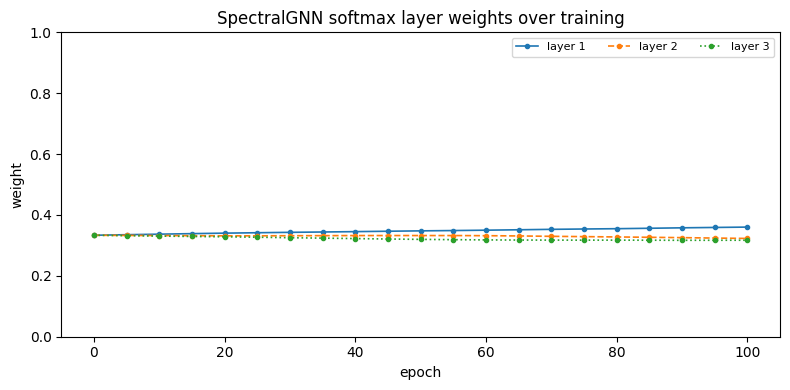

In [11]:

def plot_spectral_weights(results: dict[str, dict[str, object]]) -> None:
    payload = results.get('spectral_gnn')
    if payload is None:
        print('spectral_gnn not found in results')
        return

    embeddings = payload['embeddings']
    if 'spectral_layer_weights' not in embeddings.files:
        print('No spectral_layer_weights stored for spectral_gnn')
        return

    epochs = embeddings['epochs']
    weights = embeddings['spectral_layer_weights']

    if weights.ndim != 2 or weights.shape[1] != 3:
        print(f'Expected spectral weights shape [snapshots, 3], got {weights.shape}')
        return

    fig, ax = plt.subplots(figsize=(8, 4))
    styles = ['-', '--', ':']
    for i, label in enumerate(('layer 1', 'layer 2', 'layer 3')):
        ax.plot(epochs, weights[:, i], marker='o', ms=3, lw=1.2, ls=styles[i], label=label)

    ax.set_title('SpectralGNN softmax layer weights over training')
    ax.set_xlabel('epoch')
    ax.set_ylabel('weight')
    ax.set_ylim(0.0, 1.0)
    ax.set_xticks(epochs[::max(1, len(epochs)//5)])
    ax.legend(ncol=3, fontsize=8)
    plt.tight_layout()
    plt.show()


plot_spectral_weights(results)
